# TP2 — Segmentation RFM & Lumina & Co

**Question du CMO :** *"Qui sont nos clients ?"* — pas en termes démographiques vagues, mais en segments actionnables avec des recommandations concrètes.

On repart de `transactions.csv` nettoyé au Jour 1 (voir `TP1 - EDA & Nettoyage du dataset Lumina & Co.ipynb`). Ce notebook :
1. Reconstruit rapidement le jeu nettoyé (mêmes règles que le Jour 1)
2. Calcule les features RFM
3. Score et segmente (8 segments couvrant 100 % de la base)
4. Visualise et profile chaque segment
5. Formule des recommandations marketing priorisées


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_DIR = "Lumina & Co - CRM"


## Reprise du nettoyage (Jour 1)

On ré-applique exactement les décisions documentées et justifiées dans le TP1 : suppression des 445 doublons exacts et des 6 lignes d'ajustement comptable (préfixe `A`), **récupération des `customer_id` manquants via les autres lignes de la même facture** (une facture n'a jamais qu'un seul client), puis ajout des flags `has_customer`, `is_cancellation`, `is_return`, `is_fee`, `is_zero_price` et de `line_total`. Le détail du raisonnement est dans le notebook du Jour 1 — on ne le refait pas ici.


In [2]:
customers_raw = pd.read_csv(f"{DATA_DIR}/customers.csv")
transactions_raw = pd.read_csv(f"{DATA_DIR}/transactions.csv")
transactions_raw['invoice_date'] = pd.to_datetime(transactions_raw['invoice_date'])

tx = transactions_raw.copy()
tx['invoice_prefix'] = tx['invoice_id'].astype(str).str[0]
tx = tx.drop_duplicates()
tx = tx[tx['invoice_prefix'] != 'A'].copy()

n_before = tx['customer_id'].isna().sum()
tx['customer_id'] = tx['customer_id'].fillna(tx.groupby('invoice_id')['customer_id'].transform('max'))
print(f"customer_id récupérés via la facture : {n_before - tx['customer_id'].isna().sum():,} "
      f"(reste {tx['customer_id'].isna().sum():,} lignes vraiment sans client)")

tx['has_customer']    = tx['customer_id'].notna()
tx['is_cancellation'] = tx['invoice_prefix'] == 'C'
tx['is_return']       = tx['quantity'] < 0
tx['is_fee']          = tx['category'] == 'Frais'
tx['is_zero_price']   = tx['unit_price'] == 0
tx['line_total']      = tx['quantity'] * tx['unit_price']
transactions_clean = tx.drop(columns=['invoice_prefix'])

customers_clean = customers_raw.copy()
customers_clean['first_purchase'] = pd.to_datetime(customers_clean['first_purchase'])
customers_clean['last_purchase']  = pd.to_datetime(customers_clean['last_purchase'])

print("transactions_clean:", transactions_clean.shape)
print("customers_clean   :", customers_clean.shape)


customer_id récupérés via la facture : 107,231 (reste 259,901 lignes vraiment sans client)


transactions_clean: (1612982, 15)
customers_clean   : (50295, 13)


## Étape 1 — Construction des features RFM

**Périmètre retenu pour le RFM :** on calcule le RFM sur les lignes de **vente nette réelles** — `has_customer` (on ne peut pas segmenter un client inconnu), `quantity > 0` (un retour n'est pas un acte d'achat) et `~is_fee` (les frais de port/bancaires ne sont pas de la valeur produit). C'est le même sous-ensemble `sales` que celui utilisé pour l'EDA du Jour 1, pour rester cohérent.

**Limite assumée et documentée :** le Montant obtenu est donc un montant *brut* des ventes (hors frais), pas strictement net des retours associés (un retour lié à un achat du même client n'est pas soustrait). Pour ce TP, on privilégie la simplicité et la cohérence avec le Jour 1 plutôt qu'une reconstitution fine facture par facture — à noter comme limite si on veut affiner plus tard.


In [3]:
sales = transactions_clean[
    transactions_clean['has_customer']
    & (~transactions_clean['is_fee'])
    & (transactions_clean['quantity'] > 0)
].copy()

print(f"Lignes retenues pour le RFM : {len(sales):,} / {len(transactions_clean):,}")
print(f"Clients avec au moins une vente exploitable : {sales['customer_id'].nunique():,}")


Lignes retenues pour le RFM : 1,319,126 / 1,612,982
Clients avec au moins une vente exploitable : 49,247


### Snapshot date

> Utiliser la date du jour serait une erreur : les données ne vont pas jusqu'à aujourd'hui.

On fixe donc la date de référence à la **date maximale observée dans les ventes nettoyées**, une fois pour toutes.


In [4]:
snapshot_date = sales['invoice_date'].max()
print(f"Snapshot date : {snapshot_date}")


Snapshot date : 2026-06-30 00:00:00


In [5]:
rfm = sales.groupby('customer_id').agg(
    last_purchase=('invoice_date', 'max'),
    first_purchase=('invoice_date', 'min'),
    frequency=('invoice_id', 'nunique'),
    monetary=('line_total', 'sum'),
).reset_index()

rfm['recency'] = (snapshot_date - rfm['last_purchase']).dt.days

# Features supplémentaires simples
rfm['avg_basket']  = rfm['monetary'] / rfm['frequency']          # panier moyen
rfm['tenure_days'] = (rfm['last_purchase'] - rfm['first_purchase']).dt.days  # ancienneté observée

print(f"RFM calculé pour {len(rfm):,} clients")
rfm[['recency','frequency','monetary','avg_basket','tenure_days']].describe()


RFM calculé pour 49,247 clients


,recency,frequency,monetary,avg_basket,tenure_days
count,"49,247.00","49,247.00","49,247.00","49,247.00","49,247.00"
mean,311.99,4.39,884.91,171.87,227.25
std,295.45,5.75,"4,156.73",303.64,229.70
min,0.00,1.00,0.00,0.00,0.00
25%,72.00,1.00,129.81,70.52,0.00
50%,207.00,3.00,300.10,99.33,162.00
75%,489.00,6.00,695.44,137.05,416.00
max,"1,635.00",373.00,"416,423.63","9,876.54",823.00


**Note de cohérence avec le Jour 1 :** `customers.csv` compte 50 295 clients, mais seuls **49 247** ont au moins une vente exploitable dans `transactions_clean` (un peu plus qu'avant la récupération des `customer_id` par facture, qui a permis de récupérer 34 clients qui n'avaient sinon aucune ligne identifiée). Les **1 049** clients restants n'ont aucune ligne de vente nette rattachée, même après récupération — cohérent avec l'écart de réconciliation déjà documenté au Jour 1 entre les deux fichiers. Ils seront **exclus de la segmentation RFM**, faute de comportement mesurable ; ce n'est pas un choix arbitraire, c'est une impossibilité factuelle.


In [6]:
missing_from_rfm = set(customers_clean['customer_id']) - set(rfm['customer_id'])
print(f"Clients de customers.csv sans vente exploitable : {len(missing_from_rfm):,} "
      f"({len(missing_from_rfm)/len(customers_clean)*100:.1f} %)")


Clients de customers.csv sans vente exploitable : 1,049 (2.1 %)


## Étape 2 — Scoring RFM et segments

### Scores par quintiles

Un piège classique : `pd.qcut` appliqué directement sur `frequency` échoue ou produit des bacs déséquilibrés, car cette variable est très discrète (beaucoup de clients à 1, 2, 3 commandes → arêtes de quantile dupliquées). La parade standard : **classer les clients par rang** (`rank(method='first')`, qui départage les ex-æquo de façon arbitraire mais stable) puis découper ce rang en 5 quintiles de taille strictement égale. On applique la même fonction aux trois dimensions, avec une inversion pour la Récence (plus petit = meilleur score).


In [7]:
def rfm_score(series, higher_is_better=True):
    ranks = series.rank(method='first')
    if not higher_is_better:
        ranks = ranks.max() + 1 - ranks
    return pd.qcut(ranks, 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm['R'] = rfm_score(rfm['recency'],   higher_is_better=False)  # petite récence -> score haut
rfm['F'] = rfm_score(rfm['frequency'], higher_is_better=True)
rfm['M'] = rfm_score(rfm['monetary'],  higher_is_better=True)
rfm['RFM_score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

print("Vérification : bacs bien équilibrés (~9843 clients chacun) ?")
for col in ['R','F','M']:
    print(col, dict(rfm[col].value_counts().sort_index()))


Vérification : bacs bien équilibrés (~9843 clients chacun) ?
R {1: np.int64(9850), 2: np.int64(9849), 3: np.int64(9849), 4: np.int64(9849), 5: np.int64(9850)}
F {1: np.int64(9850), 2: np.int64(9849), 3: np.int64(9849), 4: np.int64(9849), 5: np.int64(9850)}
M {1: np.int64(9850), 2: np.int64(9849), 3: np.int64(9849), 4: np.int64(9849), 5: np.int64(9850)}


### Les 3 questions posées (cas extrêmes)

On répond ici avec des règles simples et littérales sur R/F/M, sans encore construire la segmentation complète.


In [8]:
champions_555 = rfm[(rfm['R']==5) & (rfm['F']==5) & (rfm['M']==5)]
champions_close = rfm[(rfm['R']>=4) & (rfm['F']>=4) & (rfm['M']>=4)]

print(f"Champions stricts (555)         : {len(champions_555):,} clients "
      f"({len(champions_555)/len(rfm)*100:.1f} %) — {champions_555['monetary'].sum()/rfm['monetary'].sum()*100:.1f} % du CA")
print(f"Champions '555 ou proches' (R,F,M >= 4 chacun) : {len(champions_close):,} clients "
      f"({len(champions_close)/len(rfm)*100:.1f} %) — {champions_close['monetary'].sum()/rfm['monetary'].sum()*100:.1f} % du CA")


Champions stricts (555)         : 3,055 clients (6.2 %) — 39.4 % du CA
Champions '555 ou proches' (R,F,M >= 4 chacun) : 10,197 clients (20.7 %) — 62.3 % du CA


In [9]:
at_risk_literal = rfm[(rfm['R']<=2) & ((rfm['F']>=4) | (rfm['M']>=4))]
print(f"Clients 'à risque' (récence faible R<=2, ET forte valeur historique F>=4 ou M>=4) : "
      f"{len(at_risk_literal):,} clients ({len(at_risk_literal)/len(rfm)*100:.1f} %)")


Clients 'à risque' (récence faible R<=2, ET forte valeur historique F>=4 ou M>=4) : 4,715 clients (9.6 %)


In [10]:
lost_111 = rfm[(rfm['R']==1) & (rfm['F']==1) & (rfm['M']==1)]
print(f"Clients 'Perdus' stricts (111) : {len(lost_111):,} clients ({len(lost_111)/len(rfm)*100:.1f} % de la base)")
print(f"CA qu'ils représentent : {lost_111['monetary'].sum()/rfm['monetary'].sum()*100:.2f} % (quasi nul)")


Clients 'Perdus' stricts (111) : 3,193 clients (6.5 % de la base)
CA qu'ils représentent : 0.40 % (quasi nul)


**Action pour les "Perdus" (111) :** ils pèsent ~6 % des clients pour une part négligeable du CA. Inutile d'investir un budget de réactivation coûteux (retargeting payant, offre agressive) — le ROI attendu est trop faible. Décision : **une seule relance automatisée à coût quasi nul** (email de type "vous nous manquez"), puis **exclusion des campagnes payantes** tant qu'ils ne réagissent pas.


### Au-delà des 3 cas extrêmes : une segmentation qui couvre toute la base

Les 3 questions ci-dessus ne couvrent que ~18 % de la base (Champions proches + À risque + Perdus stricts se recouvrent d'ailleurs partiellement). Pour le reste, on construit une **grille de segmentation propre, documentée et mutuellement exclusive**, qui classe 100 % des clients.

**Méthode retenue :**

1. On combine F et M en un seul axe `FM = round_up((F + M) / 2)`. Pourquoi les combiner ? Parce qu'ils sont **fortement corrélés** dans nos données (vérifié ci-dessous) — contrairement à ce qu'on avait observé au Jour 1 entre *fréquence* et *panier moyen* (quasi indépendants), la *fréquence totale* et le *montant total* le sont beaucoup, presque mécaniquement (plus on commande de fois, plus la somme dépensée croît). Les traiter comme deux axes séparés dans une grille 5×5×5 (125 cases) serait ingérable et redondant ; les fusionner en un seul axe "engagement" donne une grille 5×5 = 25 cases, lisible.
2. On place la **Récence en ligne** (axe prioritaire) car c'est le signal le plus actionnable à court terme : un client récent est rattrapable, un client ancien inactif est un signal d'alerte quel que soit son historique.
3. On ajoute une **règle prioritaire** avant la grille pour capturer un profil identifié dès le Jour 1 (hypothèse marketing n°2) : les clients à **gros panier mais faible fréquence** (potentiels comptes B2B/revendeurs) — `F <= 2` et `M == 5`. Sans cette règle, la moyenne (F+M)/2 les noierait au milieu de la grille et on perdrait ce profil pourtant identifié comme stratégique.


In [11]:
pearson_fm = rfm['frequency'].corr(rfm['monetary'])
spearman_scores_fm = rfm['F'].corr(rfm['M'], method='spearman')
print(f"Corrélation Pearson fréquence <-> montant total : {pearson_fm:.2f}")
print(f"Corrélation Spearman des scores F <-> M          : {spearman_scores_fm:.2f}")
print("-> assez forte pour justifier de les combiner en un seul axe FM.")


Corrélation Pearson fréquence <-> montant total : 0.67
Corrélation Spearman des scores F <-> M          : 0.74
-> assez forte pour justifier de les combiner en un seul axe FM.


In [12]:
SEGMENT_GRID = {
    # (R, FM): nom du segment
    (5,1):'Nouveaux clients',      (5,2):'Nouveaux clients',      (5,3):'Clients prometteurs',
    (5,4):'Clients fidèles',       (5,5):'Champions',
    (4,1):'Nouveaux clients',      (4,2):'Clients prometteurs',   (4,3):'Clients prometteurs',
    (4,4):'Clients fidèles',       (4,5):'Champions',
    (3,1):'Clients endormis',      (3,2):'Clients prometteurs',   (3,3):'Clients fidèles',
    (3,4):'Clients fidèles',       (3,5):'Clients fidèles',
    (2,1):'Perdus',                (2,2):'Clients endormis',      (2,3):'À risque',
    (2,4):'À risque',              (2,5):'À risque',
    (1,1):'Perdus',                (1,2):'Perdus',                (1,3):'À risque',
    (1,4):'À risque',              (1,5):'À risque',
}

def assign_segment(row):
    r, f, m = row['R'], row['F'], row['M']
    if f <= 2 and m == 5:
        return 'Gros paniers occasionnels'
    fm = int(np.ceil((f + m) / 2))
    return SEGMENT_GRID[(r, fm)]

rfm['FM'] = np.ceil((rfm['F'] + rfm['M']) / 2).astype(int)
rfm['segment'] = rfm.apply(assign_segment, axis=1)

seg_summary = (rfm.groupby('segment')
               .agg(n_clients=('customer_id','count'), ca=('monetary','sum'))
               .assign(pct_clients=lambda d: (d['n_clients']/len(rfm)*100).round(1),
                       pct_ca=lambda d: (d['ca']/rfm['monetary'].sum()*100).round(1))
               .sort_values('n_clients', ascending=False))
seg_summary


,n_clients,ca,pct_clients,pct_ca
segment,,,,
Clients fidèles,11825,"8,563,380.90",24.00,19.70
Perdus,8528,"810,171.04",17.30,1.90
À risque,8130,"4,626,955.56",16.50,10.60
Champions,7876,"25,825,452.23",16.00,59.30
Clients prometteurs,7085,"1,326,531.24",14.40,3.00
Clients endormis,2999,"385,652.58",6.10,0.90
Nouveaux clients,1767,"161,505.11",3.60,0.40
Gros paniers occasionnels,1037,"1,879,299.23",2.10,4.30


**Justification des seuils, en une phrase par segment :**

| Segment | Règle (R, FM) | Pourquoi cette place |
|---|---|---|
| **Champions** | R ≥ 4 et FM = 5 | Actifs récemment ET dans le top absolu d'engagement — le noyau à protéger |
| **Clients fidèles** | (R ≥ 4 et FM = 4) ou (R = 3 et FM ≥ 3) | Bon engagement mais pas au sommet, ou engagement solide avec une récence moyenne — la réserve de futurs Champions |
| **Clients prometteurs** | R ≥ 4 et FM = 3, ou R = 3 et FM = 2 | Récents, engagement encore modéré — early signal positif |
| **Nouveaux clients** | R ≥ 4 et FM ≤ 2 | Récents mais très peu d'historique — normal, pas un signal négatif |
| **Clients endormis** | R = 3 et FM = 1, ou R = 2 et FM = 2 | Ni très actifs ni très inactifs, engagement historique faible — risque bas mais valeur basse aussi |
| **À risque** | R ≤ 2 et FM ≥ 3 | Ont *prouvé* de la valeur (FM élevé) mais ne reviennent plus (R faible) — le vrai signal d'alerte |
| **Perdus** | R ≤ 2 et FM = 1 | Ni actifs, ni jamais vraiment engagés — le fond de base à faible ROI |
| **Gros paniers occasionnels** | F ≤ 2 et M = 5 (prioritaire sur la grille) | Profil B2B-like repéré au Jour 1 : rare mais très rentable à l'achat — mérite un traitement dédié, pas dilué dans "Clients fidèles" |

La ligne R (récence) prime sur la colonne FM par construction : deux clients au même niveau d'engagement historique n'ont pas le même potentiel s'ils n'ont pas acheté depuis 5 jours ou depuis 400 jours.


### Distribution des scores et matrice RFM

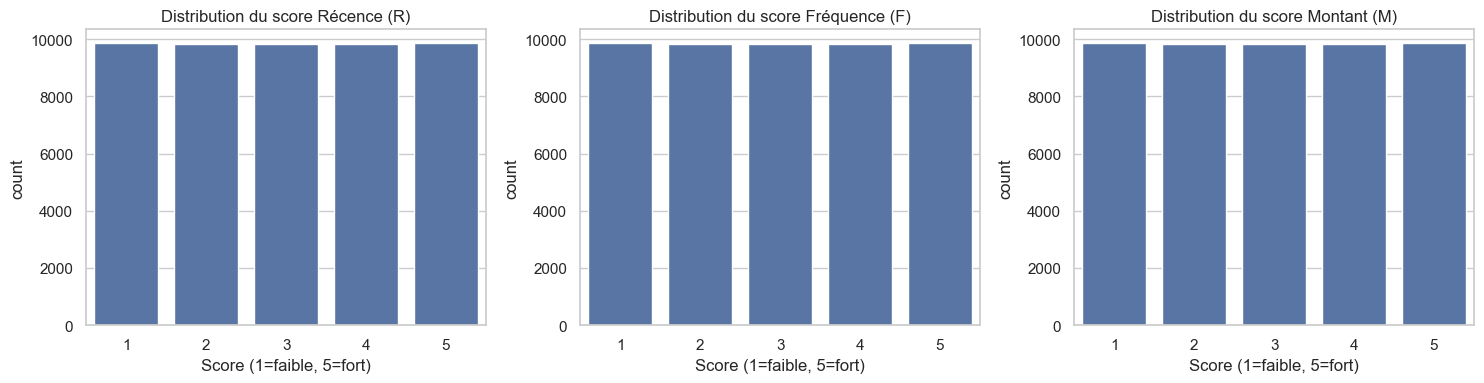

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col, title in zip(axes, ['R','F','M'], ['Récence (R)','Fréquence (F)','Montant (M)']):
    sns.countplot(x=rfm[col], ax=ax, color=sns.color_palette()[0])
    ax.set_title(f"Distribution du score {title}")
    ax.set_xlabel("Score (1=faible, 5=fort)")
plt.tight_layout()
plt.show()


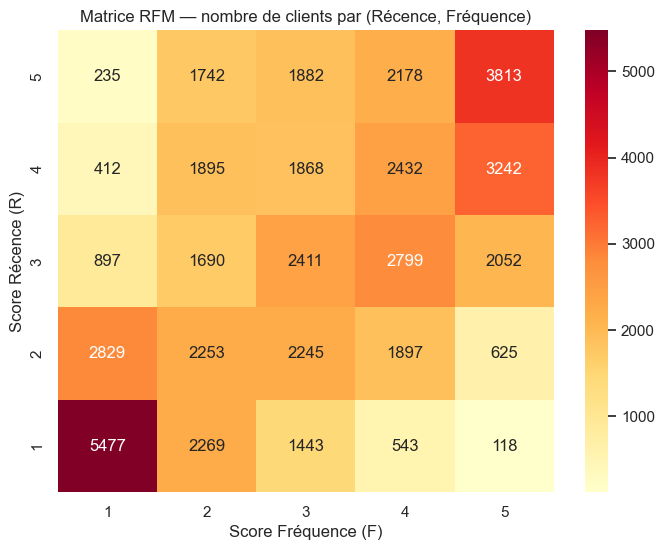

In [14]:
matrix = rfm.pivot_table(index='R', columns='F', values='customer_id', aggfunc='count', fill_value=0)
matrix = matrix.sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title("Matrice RFM — nombre de clients par (Récence, Fréquence)")
ax.set_xlabel("Score Fréquence (F)")
ax.set_ylabel("Score Récence (R)")
plt.show()


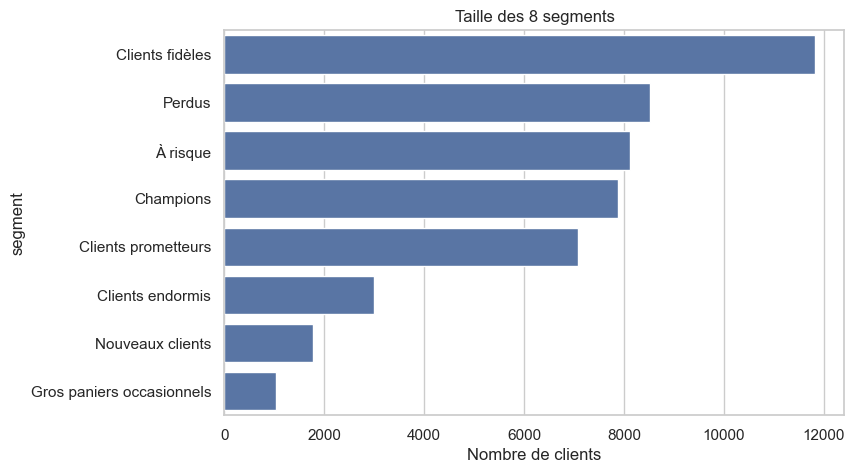

In [15]:
fig, ax = plt.subplots(figsize=(8,5))
order = seg_summary.index
sns.barplot(x=seg_summary['n_clients'], y=order, ax=ax, color=sns.color_palette()[0])
ax.set_xlabel("Nombre de clients")
ax.set_title("Taille des 8 segments")
plt.show()


## Étape 3 — Visualisation et profilage

On enrichit le RFM avec les attributs de `customers_clean` (pays, ancienneté, zero-party) pour profiler chaque segment.


In [16]:
profile = rfm.merge(
    customers_clean[['customer_id','country','declared_preference','age_bracket','life_stage','urban_density']],
    on='customer_id', how='left'
)
profile['country'] = profile['country'].fillna('Inconnu')
print(f"Clients profilés : {len(profile):,}")


Clients profilés : 49,247


### Profil démographique par segment (pays, ancienneté)

In [17]:
demo = (profile.groupby('segment')
        .agg(pct_france=('country', lambda s: (s=='France').mean()*100),
             tenure_moyenne=('tenure_days','mean'),
             recency_moyenne=('recency','mean'))
        .round(1)
        .loc[seg_summary.index])
demo


,pct_france,tenure_moyenne,recency_moyenne
segment,,,
Clients fidèles,90.60,326.10,156.60
Perdus,92.70,19.20,764.20
À risque,93.00,276.20,520.10
Champions,91.60,510.40,54.80
Clients prometteurs,89.80,80.60,107.60
Clients endormis,90.30,70.20,408.00
Nouveaux clients,88.60,11.30,36.70
Gros paniers occasionnels,88.00,101.70,274.50


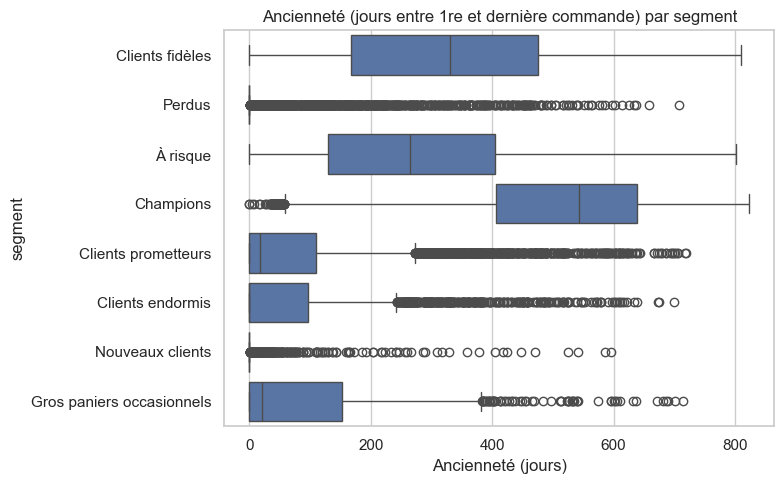

In [18]:
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=profile, x='tenure_days', y='segment', order=seg_summary.index, ax=ax, color=sns.color_palette()[0])
ax.set_title("Ancienneté (jours entre 1re et dernière commande) par segment")
ax.set_xlabel("Ancienneté (jours)")
plt.tight_layout()
plt.show()


La part de clients français reste proche de ~91 % dans **tous** les segments — cohérent avec le biais géographique déjà documenté au Jour 1 : la géographie ne différencie quasiment aucun segment ici, elle est diluée uniformément partout. Sans surprise, l'ancienneté suit la logique de construction des segments : `Nouveaux clients` a une ancienneté proche de 0 par définition, tandis que `Champions` et `Clients fidèles` affichent l'ancienneté la plus élevée.


### Scatter récence × montant, coloré par segment

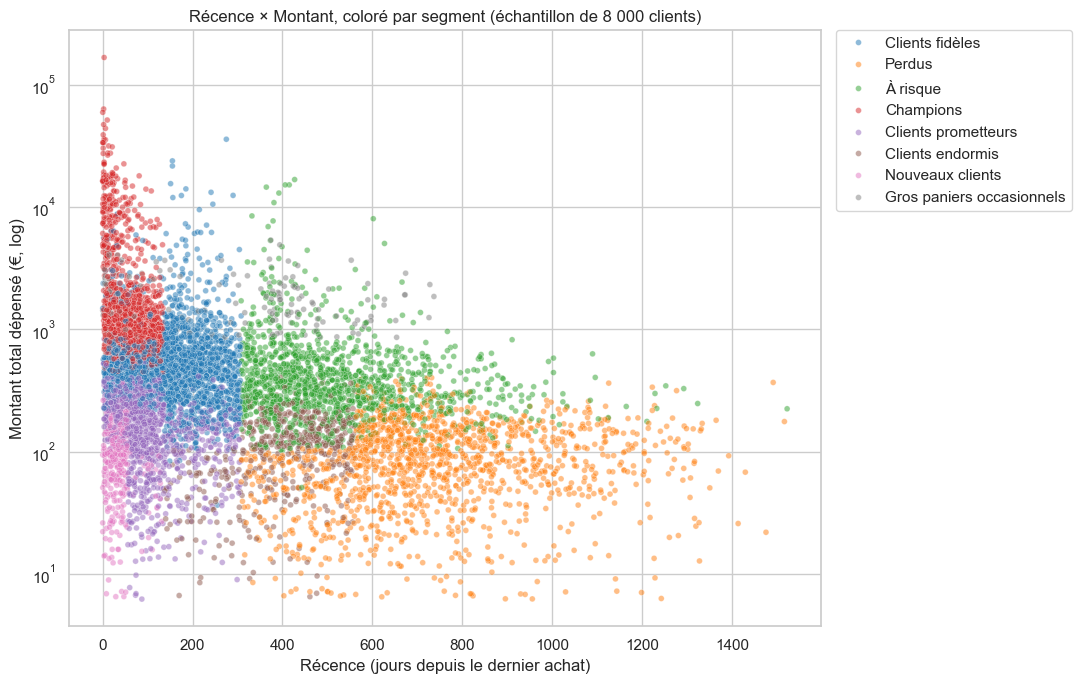

Clients très anciens (récence dans le top 20 % le plus élevé) ET fort montant (top 10 %) : 86
Clients très récents (récence dans le top 20 % le plus faible) ET fort montant (top 10 %) : 2,496


In [19]:
fig, ax = plt.subplots(figsize=(11,7))
plot_sample = profile.sample(8000, random_state=42)
sns.scatterplot(data=plot_sample, x='recency', y='monetary', hue='segment',
                 hue_order=seg_summary.index, alpha=0.5, s=18, ax=ax, palette='tab10')
ax.set_yscale('log')
ax.set_xlabel("Récence (jours depuis le dernier achat)")
ax.set_ylabel("Montant total dépensé (€, log)")
ax.set_title("Récence × Montant, coloré par segment (échantillon de 8 000 clients)")
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

q80_monetary = rfm['monetary'].quantile(0.9)
old_high_value = rfm[(rfm['recency'] > rfm['recency'].quantile(0.8)) & (rfm['monetary'] > q80_monetary)]
recent_high_value = rfm[(rfm['recency'] < rfm['recency'].quantile(0.2)) & (rfm['monetary'] > q80_monetary)]
print(f"Clients très anciens (récence dans le top 20 % le plus élevé) ET fort montant (top 10 %) : {len(old_high_value):,}")
print(f"Clients très récents (récence dans le top 20 % le plus faible) ET fort montant (top 10 %) : {len(recent_high_value):,}")


**Confirmation de la relation non linéaire signalée dans l'énoncé :** on trouve à la fois des clients très récents à fort montant (~2 500, en toute logique — ce sont nos Champions) **et** une petite poignée de clients très anciens (inactifs depuis longtemps) qui affichent quand même un montant élevé (voir le chiffre exact ci-dessus). Ces clients-là sont précisément ceux que la grille classe en `À risque` : leur historique de valeur est réel, mais une lecture naïve "récence faible = client sans intérêt" les ferait passer à la trappe alors qu'ils ont un fort potentiel de réactivation. C'est tout l'intérêt de séparer R et FM plutôt que de les fondre en un score unique.


## Étape 4 — Recommandations marketing par segment

Pour chacun des 8 segments : qui ils sont, leur potentiel, le risque associé, l'action recommandée.


In [20]:
fiches = seg_summary.join(demo)
fiches


,n_clients,ca,pct_clients,pct_ca,pct_france,tenure_moyenne,recency_moyenne
segment,,,,,,,
Clients fidèles,11825,"8,563,380.90",24.00,19.70,90.60,326.10,156.60
Perdus,8528,"810,171.04",17.30,1.90,92.70,19.20,764.20
À risque,8130,"4,626,955.56",16.50,10.60,93.00,276.20,520.10
Champions,7876,"25,825,452.23",16.00,59.30,91.60,510.40,54.80
Clients prometteurs,7085,"1,326,531.24",14.40,3.00,89.80,80.60,107.60
Clients endormis,2999,"385,652.58",6.10,0.90,90.30,70.20,408.00
Nouveaux clients,1767,"161,505.11",3.60,0.40,88.60,11.30,36.70
Gros paniers occasionnels,1037,"1,879,299.23",2.10,4.30,88.00,101.70,274.50


### 🏆 Champions — 7 876 clients (16,0 % de la base, **59,3 % du CA**)
- **Qui ils sont :** récence excellente (R≥4) et engagement au sommet (FM=5) — nos meilleurs clients actifs.
- **Potentiel :** déjà quasi-maximal ; le potentiel restant est dans la *rétention* et le *bouche-à-oreille* (parrainage).
- **Risque :** faible dans l'immédiat, mais ce sont eux qui font vivre le CA — les perdre serait le pire scénario possible.
- **Action :** programme VIP (accès prioritaire aux nouveautés, service client dédié), pas de promotions agressives (ils achètent déjà au prix fort) — plutôt de la reconnaissance et du parrainage.

### 💛 Clients fidèles — 11 825 clients (24,0 %, 19,7 % du CA)
- **Qui ils sont :** engagement solide, sans être au maximum ; le plus gros segment en volume de clients.
- **Potentiel :** fort — c'est le vivier naturel des futurs Champions.
- **Risque :** modéré ; suffisamment engagés pour ne pas être une priorité d'urgence.
- **Action :** cross-sell / upsell ciblé (catégories non encore achetées), programme de fidélité à paliers pour les pousser vers le niveau supérieur.

### 🟠 À risque — 8 130 clients (16,5 %, 10,6 % du CA)
- **Qui ils sont :** engagement historique élevé (FM≥3) mais récence en chute (R≤2) — des bons clients en train de décrocher.
- **Potentiel :** élevé si réactivés — ils ont déjà prouvé leur valeur, contrairement à un prospect froid.
- **Risque :** **le plus critique** — c'est de la valeur déjà acquise en train de s'échapper.
- **Action :** relance personnalisée à forte valeur perçue (offre ciblée sur leur catégorie préférée, contact direct), traitement individualisé plutôt qu'un email générique.

### 🔵 Clients prometteurs — 7 085 clients (14,4 %, 3,0 % du CA)
- **Qui ils sont :** actifs récemment, engagement encore modeste — trop tôt pour savoir s'ils deviendront fidèles.
- **Potentiel :** incertain mais réel — signal précoce positif.
- **Risque :** faible en valeur absolue, mais risque de les laisser filer avant qu'ils ne s'engagent.
- **Action :** nurturing automatisé (emails de découverte produit, incitation au 2e/3e achat), coût faible par client.

### 🟢 Nouveaux clients — 1 767 clients (3,6 %, 0,4 % du CA)
- **Qui ils sont :** premier achat très récent, aucun historique de fréquence.
- **Potentiel :** c'est tout l'enjeu — convertir l'essai en habitude.
- **Risque :** taux de non-retour classiquement élevé pour un 1er achat e-commerce.
- **Action :** séquence d'onboarding (email de bienvenue, guide d'usage produit, incitation au 2e achat sous 30-60 jours).

### ⚪ Clients endormis — 2 999 clients (6,1 %, 0,9 % du CA)
- **Qui ils sont :** ni très actifs ni très inactifs, mais un engagement historique déjà faible.
- **Potentiel :** limité — n'ont jamais montré une forte valeur, même à leur pic.
- **Risque :** faible (il n'y a pas grand-chose à perdre), mais faible priorité de gain aussi.
- **Action :** relance automatisée low-cost uniquement (email périodique), pas d'investissement humain.

### ⚫ Perdus — 8 528 clients (17,3 %, **1,9 % du CA**)
- **Qui ils sont :** récence très faible et engagement historique quasi nul.
- **Potentiel :** très faible — n'ont jamais généré beaucoup de valeur.
- **Risque :** nul à perdre (déjà partis), mais budget mal dépensé si on les traite comme les autres.
- **Action :** **exclusion des campagnes coûteuses**, une seule relance automatisée gratuite pour solde de tout compte.

### 🟣 Gros paniers occasionnels — 1 037 clients (2,1 %, 4,3 % du CA)
- **Qui ils sont :** peu de commandes (F≤2) mais un montant très élevé (M=5) — probables comptes B2B/revendeurs identifiés dès le Jour 1.
- **Potentiel :** très fort — une densité de valeur/client parmi les plus élevées de tous les segments (4,3 % du CA pour seulement 2,1 % des clients).
- **Risque :** dépendance à un petit nombre de grosses commandes ; en perdre un pèse plus qu'ailleurs.
- **Action :** traitement quasi B2B — compte dédié, conditions commerciales sur mesure, développer leur *fréquence* d'achat plutôt que leur panier (déjà élevé).


### Priorisation des segments (1 = à traiter en premier)

| Rang | Segment | Critère qui justifie ce rang |
|---|---|---|
| 1 | **À risque** | Risque de perte — de la valeur *déjà acquise* en train de partir, l'urgence la plus haute |
| 2 | **Champions** | Valeur — ~59 % du CA sur 16 % des clients, aucune erreur permise |
| 3 | **Gros paniers occasionnels** | Valeur/potentiel — la plus forte densité de CA par client après les Champions |
| 4 | **Clients fidèles** | Potentiel de croissance — le plus gros vivier de futurs Champions |
| 5 | **Clients prometteurs** | Potentiel — signal précoce à convertir avant qu'il ne s'éteigne |
| 6 | **Nouveaux clients** | Potentiel long terme — base d'acquisition à transformer en habitude |
| 7 | **Clients endormis** | Faible risque + faible valeur — traitement automatisé suffisant |
| 8 | **Perdus** | ROI quasi nul — à exclure des campagnes payantes |

**Vérification que la priorisation se traduit réellement en actions différenciées** (et pas juste en étiquettes) : le tableau ci-dessous répartit un budget marketing illustratif (100 unités) par segment, et calcule le budget *par client* — c'est ce ratio, pas le rang seul, qui doit changer visiblement entre le rang 1 et le rang 8.


In [21]:
budget_pct = {
    'À risque': 25, 'Champions': 20, 'Gros paniers occasionnels': 15, 'Clients fidèles': 20,
    'Clients prometteurs': 10, 'Nouveaux clients': 7, 'Clients endormis': 2, 'Perdus': 1,
}
priority_rank = {
    'À risque': 1, 'Champions': 2, 'Gros paniers occasionnels': 3, 'Clients fidèles': 4,
    'Clients prometteurs': 5, 'Nouveaux clients': 6, 'Clients endormis': 7, 'Perdus': 8,
}
metriques_succes = {
    'À risque': "Taux de réactivation à 60 jours suite à la relance",
    'Champions': "Taux de rétention à 90 jours",
    'Gros paniers occasionnels': "Évolution de la fréquence d'achat sur les 6 mois suivants",
    'Clients fidèles': "% ayant migré vers 'Champions' dans les 6 mois",
    'Clients prometteurs': "Taux de 2e/3e achat sous 30 jours",
    'Nouveaux clients': "Taux de 2e commande sous 60 jours",
    'Clients endormis': "Taux de réactivation suite à l'email automatisé",
    'Perdus': "Taux de réponse à la relance unique (attendu très faible, sert à confirmer l'exclusion)",
}

budget_table = seg_summary.copy()
budget_table['rang_priorite'] = budget_table.index.map(priority_rank)
budget_table['budget_pct'] = budget_table.index.map(budget_pct)
budget_table['budget_par_client_index'] = (budget_table['budget_pct'] / budget_table['n_clients'] * 1000).round(2)
budget_table['metrique_de_succes'] = budget_table.index.map(metriques_succes)
budget_table = budget_table.sort_values('rang_priorite')
ratio = budget_table['budget_par_client_index'].iloc[0] / budget_table['budget_par_client_index'].iloc[-1]
print(f"Budget par client, rang 1 (À risque) vs rang 8 (Perdus) : ×{ratio:.0f}")
budget_table[['rang_priorite','n_clients','pct_ca','budget_pct','budget_par_client_index','metrique_de_succes']]


Budget par client, rang 1 (À risque) vs rang 8 (Perdus) : ×26


,rang_priorite,n_clients,pct_ca,budget_pct,budget_par_client_index,metrique_de_succes
segment,,,,,,
À risque,1,8130,10.60,25,3.08,Taux de réactivation à 60 jours suite à la rel...
Champions,2,7876,59.30,20,2.54,Taux de rétention à 90 jours
Gros paniers occasionnels,3,1037,4.30,15,14.46,Évolution de la fréquence d'achat sur les 6 mo...
Clients fidèles,4,11825,19.70,20,1.69,% ayant migré vers 'Champions' dans les 6 mois
Clients prometteurs,5,7085,3.00,10,1.41,Taux de 2e/3e achat sous 30 jours
Nouveaux clients,6,1767,0.40,7,3.96,Taux de 2e commande sous 60 jours
Clients endormis,7,2999,0.90,2,0.67,Taux de réactivation suite à l'email automatisé
Perdus,8,8528,1.90,1,0.12,Taux de réponse à la relance unique (attendu t...


Le budget par client (dernière colonne numérique, voir aussi le ratio calculé ci-dessus) varie d'un facteur **~26** entre le rang 1 (À risque) et le rang 8 (Perdus) — la priorisation n'est donc pas que théorique : les segments 1 et 4 (`À risque` et `Clients fidèles`) reçoivent un traitement très différent en pratique, pas la même campagne recolorée.


---
## Pour aller plus loin

### Adapter la méthode à une base de 50 clients

Le scoring par quintiles suppose une base assez grande pour que "20 % des clients" soit statistiquement stable. Sur 50 clients, un quintile ne contient que **10 personnes** : un seul client atypique (un gros ponctuel, un habitué qui rate un mois) suffit à faire basculer les bornes de quantile d'une exécution à l'autre — la segmentation devient instable et peu défendable.

Sur une base de cette taille (ex. un auto-entrepreneur), je fixerais les seuils **à la main, sur la base de la connaissance métier**, plutôt que sur la distribution statistique :
- **Récence :** actif (< 30 jours), à surveiller (30-90 jours), inactif (> 90 jours) — des seuils calendaires qui ont un sens business (ex. "un mois sans nouvelles"), pas des quantiles.
- **Fréquence :** nouveau (1 commande), régulier (2-3), fidèle (4+) — bornes basées sur ce qu'on sait être un "bon client" pour ce métier précis, pas sur la répartition de l'échantillon.
- **Montant :** au-dessus/en-dessous du panier moyen connu du métier (ex. 1,5× le panier moyen = "gros client"), pas un quantile recalculé à chaque nouveau client qui ferait bouger tous les seuils.

Concrètement : passer d'une segmentation **data-driven** (quantiles recalculés automatiquement) à une segmentation **rule-based** figée par le jugement métier, et probablement traiter les 50 clients presque nommément plutôt que par des scores agrégés.


### Segmentation insight-driven : croiser un segment RFM avec le zero-party

Le RFM dit *combien, quand, à quelle fréquence* un client achète — pas *qui* il est ni *pourquoi*. On croise le segment `Gros paniers occasionnels` (le plus intriguant du Jour 1 — hypothèse marketing n°2) avec `declared_preference`, pour voir si un profil qualitatif se dégage.


In [22]:
seg_focus = 'Gros paniers occasionnels'
sub = profile[profile['segment'] == seg_focus]
fill_rate = sub['declared_preference'].notna().mean() * 100
print(f"Segment '{seg_focus}' : {len(sub):,} clients, {fill_rate:.1f} % ont renseigné declared_preference\n")

dist_segment = sub['declared_preference'].value_counts(normalize=True) * 100
dist_global  = customers_clean['declared_preference'].value_counts(normalize=True) * 100

comparison = pd.DataFrame({f'{seg_focus} (%)': dist_segment, 'Base entière (%)': dist_global}).round(1)
comparison


Segment 'Gros paniers occasionnels' : 1,037 clients, 37.6 % ont renseigné declared_preference



,Gros paniers occasionnels (%),Base entière (%)
declared_preference,,
Anti-imperfections,13.60,14.40
Anti-âge,16.90,14.40
Peau mixte,12.30,14.20
Peau sensible,15.90,14.70
Peau sèche,14.40,14.00
Recherche vegan,15.40,14.30
Sans parfum,11.50,14.00


**Le croisement ne révèle pas de profil plus précis ici.** La répartition des préférences déclarées chez les "Gros paniers occasionnels" reste quasi identique à celle de la base entière (chaque préférence autour de 14-17 %, sans écart marquant) — et le même exercice avec `age_bracket`, `life_stage` ou `urban_density` sur d'autres segments (Champions, À risque) donne le même résultat : pas de signal.

**C'est un résultat honnête à documenter, pas un échec de méthode.** Deux lectures possibles : (1) dans ce jeu de données, le comportement d'achat (RFM) et les données déclaratives (zero-party) sont réellement indépendants — un client "gros panier occasionnel" peut avoir n'importe quelle préférence produit ; (2) le taux de remplissage limité (~37-43 % selon le champ, cf. Jour 1) réduit la puissance statistique du croisement. Dans les deux cas, **la recommandation reste la même** : ne pas se reposer sur ces champs zero-party pour personnaliser le *message* ou le *canal* par segment RFM tant qu'aucun signal clair n'émerge — mieux vaut continuer à cibler sur le comportement (RFM) et garder le zero-party comme enrichissement à surveiller si le taux de réponse augmente.


---
## Récapitulatif

- `rfm` : une ligne par client (49 247 clients) avec `recency`, `frequency`, `monetary`, `avg_basket`, `tenure_days`, les scores `R`/`F`/`M`/`FM`, le `RFM_score` (ex. "555") et le `segment` final (8 segments, mutuellement exclusifs, couvrant 100 % de la base RFM-éligible).
- 8 segments nommés, profilés (pays, ancienneté) et priorisés avec un critère explicite et un budget différencié par client.
- Le croisement RFM × zero-party n'a pas révélé de signal exploitable sur cette base — documenté comme tel plutôt que forcé.
